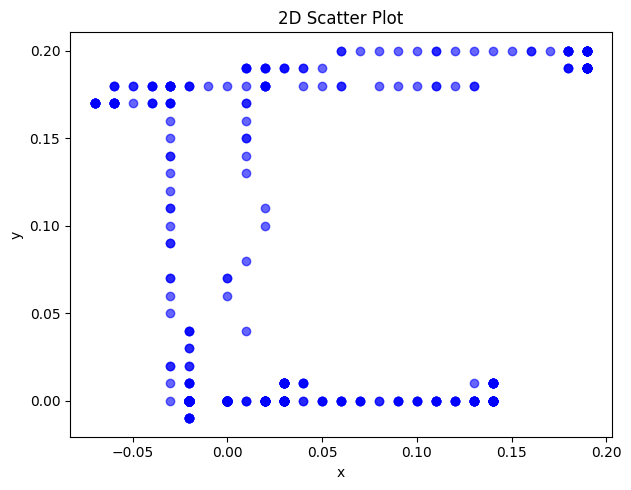

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Replace 'your_data.csv' with your actual CSV file path
df = pd.read_csv('zed_pose_log.csv')

# Assuming the CSV has columns named 'x', 'y', 'z'
fig = plt.figure(figsize=(12, 5))

# 2D Plot
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(df['x'], df['y'], c='blue', alpha=0.6)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('2D Scatter Plot')

plt.tight_layout()
plt.show()

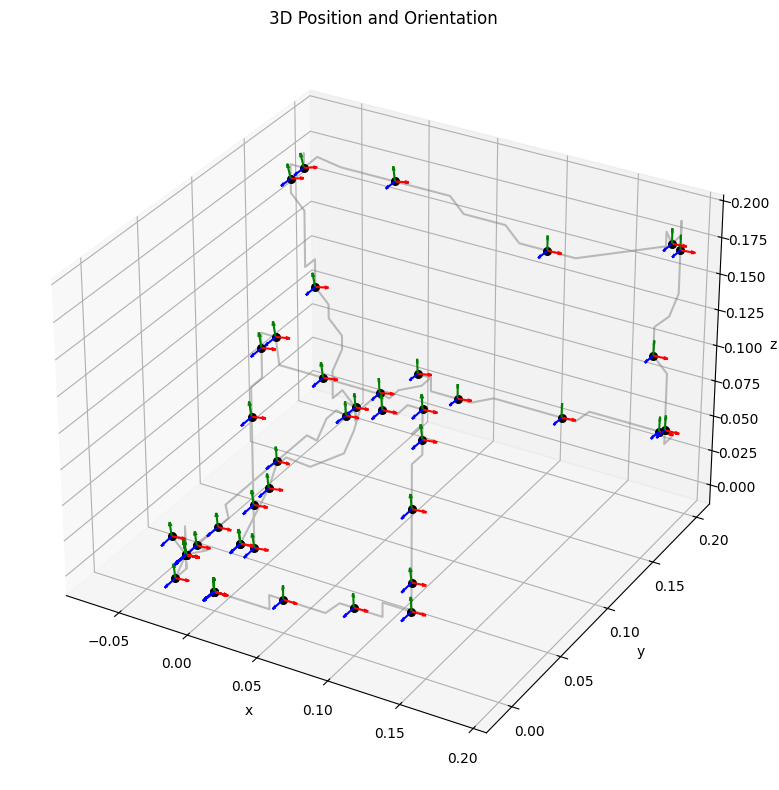

In [23]:
import numpy as np

def quat_to_rot_matrix(qx, qy, qz, qw):
    norm = np.sqrt(qx**2 + qy**2 + qz**2 + qw**2)
    qx, qy, qz, qw = qx/norm, qy/norm, qz/norm, qw/norm
    R = np.array([
        [1 - 2*(qy**2 + qz**2),     2*(qx*qy - qz*qw),     2*(qx*qz + qy*qw)],
        [    2*(qx*qy + qz*qw), 1 - 2*(qx**2 + qz**2),     2*(qy*qz - qx*qw)],
        [    2*(qx*qz - qy*qw),     2*(qy*qz + qx*qw), 1 - 2*(qx**2 + qy**2)]
    ])
    return R

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('3D Position and Orientation')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Plot trajectory
ax.plot(df['x'], df['y'], df['z'], color='gray', alpha=0.5)

axis_length = 0.01
for i in range(0, len(df), N):
    pos = df.iloc[i][['x', 'y', 'z']].values
    qx, qy, qz, qw = df.iloc[i][['qx', 'qy', 'qz', 'qw']].values
    R = quat_to_rot_matrix(qx, qy, qz, qw)
    # Draw sphere
    ax.scatter(pos[0], pos[1], pos[2], color='k', s=30)
    # Draw axes
    for axis, color in zip(np.eye(3), ['r', 'g', 'b']):
        vec = R @ axis * axis_length
        ax.quiver(pos[0], pos[1], pos[2], vec[0], vec[1], vec[2], color=color, length=axis_length, normalize=True)

plt.tight_layout()
plt.show()

